<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/Entornos_Complejos/MonteCarloOffPolicy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7'):
        !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/Entornos_Complejos

# **Monte Carlo Off-Policy con Muestreo por Importancia Ponderado**

_Ejemplo de uso de Gymnasium e informe sobre un experimento de aprendizaje por refuerzo_

Este notebook implementa el algoritmo de **Monte Carlo off-policy** (Algoritmo 6 de Sutton & Barto, 2018) sobre el entorno FrozenLake de Gymnasium. A diferencia del enfoque on-policy, aquí se usan **dos políticas distintas**:

- **Política de comportamiento $b$** (behavior policy): $\varepsilon$-greedy sobre Q. Genera los episodios de entrenamiento. Debe ser *$\varepsilon$-soft* para garantizar cobertura de todas las acciones.
- **Política objetivo $\pi$** (target policy): greedy sobre Q. Es la política que se mejora y que el agente seguirá tras el entrenamiento.

La diferencia entre las dos políticas se corrige mediante **muestreo por importancia ponderado**, que reescala cada retorno $G_t$ por el ratio $\rho = \pi(A_t|S_t) / b(A_t|S_t)$. Como $\pi$ es greedy determinista ($\pi(a|s) \in \{0, 1\}$), el ratio es 0 en cuanto se toma una acción no-greedy, por lo que el bucle de retropropagación se interrumpe en ese punto.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de Dependencias**: Se instalan las librerías necesarias para utilizar el entorno `gymnasium`.
- **Importación de Librerías**: `numpy`, `matplotlib` y `tqdm`.
- **Importación del Entorno "FrozenLake"**: Se cargan dos versiones (4x4 y 8x8) sin deslizamiento (`is_slippery=False`).

##### _________ **Código de la Instalación e Importación**
----

In [7]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [8]:
import sys
sys.path.insert(0, 'src')

#@title Importamos librerias

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import MonteCarloOffPolicyAgent
from plotting import plot, plot_lengths, plot_scenario

In [9]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

import os
np.random.seed(SEED)
np.random.default_rng(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [10]:
#@title Importamos el lago helado
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi")
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi")


# Fijar la semilla en los entornos (patrón sección 5.4 del PDF)
env4.reset(seed=SEED)
env8.reset(seed=SEED)


(0, {'prob': 1})

## **2. Diseño del Agente**

El agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### Políticas
- **$\varepsilon$-soft** (`random_epsilon_greedy_policy`): distribución base con $\pi(a|s) \geq \varepsilon/|A|$.
- **$\varepsilon$-greedy** (`epsilon_greedy_policy`): muestrea una acción desde la $\varepsilon$-soft. Usada por $b$.
- **Greedy** (`pi_star_from_Q`): $\pi(s) = \arg\max_a Q(s,a)$. Usada como política objetivo $\pi$.

### Algoritmo: MC Off-Policy con IS Ponderado (Algoritmo 6)
Al finalizar cada episodio, se recorre en sentido inverso:

$$G \leftarrow r + \gamma G$$
$$C(s,a) \leftarrow C(s,a) + W$$
$$Q(s,a) \leftarrow Q(s,a) + \frac{W}{C(s,a)}\bigl[G - Q(s,a)\bigr]$$
$$\text{Si } a \neq \arg\max_{a'} Q(s,a') \Rightarrow \text{cortar el bucle}$$
$$W \leftarrow W \cdot \frac{1}{b(a|s)}$$

donde $C(s,a)$ acumula los pesos de importancia (denominador del IS ponderado) y $W$ empieza en 1 al inicio de cada retropropagación.

**¿Por qué se corta el bucle?** Porque $\pi$ es greedy determinista: $\pi(a|s) = 0$ para toda acción no-greedy. Por tanto $W = W \cdot \pi(a|s)/b(a|s) = 0$ y los pasos anteriores no contribuirían a ninguna actualización.

#### **Código de las políticas y algoritmo MC Off-Policy**
----------------

In [11]:
# @title Acciones del entorno FrozenLake
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

In [12]:
# @title Agente Monte Carlo Off-Policy — importado de agents/monte_carlo_off_policy_agent.py
# MonteCarloOffPolicyAgent implementa el Algoritmo 6 de Sutton & Barto (2018):
#   - política de comportamiento b: epsilon-greedy (genera episodios)
#   - política objetivo pi: greedy pura (la que se mejora)
#   - bucle backward con break cuando accion != argmax Q[s]
#   - acumulador C(s,a) para IS ponderado
#   - q_init opcional: inicialización aleatoria en [0, q_init] para romper sesgo argmax
#   - método train(num_episodes), stats(), pi_star()

## **3. Experimentación**

Se entrena el agente off-policy en el entorno 4x4 y 8x8 con 50 000 episodios.

- En el escenario **4x4** se usa $\varepsilon = 0.4$ constante.
- En el escenario **8x8** se usa $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\, 1000/(t+1))$.

En cada experimento se muestran:
1. La proporción acumulada de recompensas $f(t) = \frac{\sum_{i=1}^t R_i}{t}$.
2. La longitud de los episodios $f(t) = \text{len}(\text{episodio}_t)$ con su media móvil.
3. La tabla de valores $Q$ aprendida.
4. El escenario FrozenLake con las flechas de la política óptima.
5. La secuencia de acciones de la política óptima greedy.

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Proporción de recompensas:** $f(t)=\frac{\sum_{i=1}^t R_i}{t}$

Como la recompensa es 1 si se llega a la meta y 0 en caso contrario (sin descuento, $\gamma=1$), esta media acumulada es directamente la **tasa de éxito**.

---

**Gráfica 2 — Longitud de los episodios:** $f(t) = \text{len}(\text{episodio}_t)$

En el caso off-policy esta gráfica tiene una interpretación adicional respecto al caso on-policy. Recuérdese que el bucle de retropropagación se **interrumpe** en cuanto se toma una acción no-greedy (porque el peso $W$ se haría 0). Esto significa que:

- Al inicio del entrenamiento, cuando $\varepsilon$ es alto, casi todos los pasos son potencialmente no-greedy y el agente solo actualiza **la cola greedy** de cada episodio (pocos pasos).
- A medida que $Q$ mejora, más acciones coinciden con la greedy y el agente puede propagar el retorno más atrás en el episodio.
- Con decaimiento de $\varepsilon$, la política de comportamiento $b$ se acerca a $\pi$ y los pesos $W = 1/b(a|s)$ se aproximan a 1, reduciendo la varianza de las estimaciones.

La curva de longitud muestra las mismas 3 fases que en on-policy (corto-aleatorio → largo-subóptimo → estable-óptimo), pero la convergencia puede ser más lenta en las primeras fases porque muchos episodios contribuyen poco a la actualización de $Q$.

In [13]:
# @title Funciones de visualización — importadas de plotting/plotting.py
# plot(list_stats)               → proporción de recompensas por episodio
# plot_lengths(list_lengths)     → longitud de episodios con media móvil
# plot_scenario(env, Q, title)   → grid FrozenLake con flechas de política óptima

### **3.2 Experimentación en el escenario 4x4**

Se realizan 50 000 episodios con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\, 1000/(t+1))$.

A diferencia del caso on-policy, el off-policy **requiere decay en ambos entornos**. Con $\varepsilon$ constante alto (e.g. 0.4), el backward pass se interrumpe en casi todos los pasos no-greedy, y la probabilidad de que los k pasos de un episodio sean todos greedy es $0.7^k$. Para el camino óptimo de 6 pasos en 4x4, solo el $\approx 12\%$ de los episodios exitosos propagan el retorno completo. El decay hace que $\varepsilon \to 0$ progresivamente, lo que permite que el backward pass llegue cada vez más lejos y los pesos $W = 1/b(a|s)$ se aproximen a 1, reduciendo la varianza.

In [28]:
# @title Aprendizaje
agent4 = MonteCarloOffPolicyAgent(env4, epsilon=0.4, decay=True, discount_factor=1.0)
agent4.train(num_episodes=50000)
list_stats, list_lengths = agent4.stats()
Q = agent4.q_values

 10%|█         | 5248/50000 [00:03<00:28, 1562.25it/s]

success: 0.2080, epsilon: 0.2000


 21%|██        | 10392/50000 [00:05<00:12, 3201.61it/s]

success: 0.4184, epsilon: 0.1000


 31%|███       | 15598/50000 [00:07<00:09, 3497.34it/s]

...

success: 0.8198, epsilon: 0.0250


 91%|█████████ | 45414/50000 [00:15<00:01, 3569.97it/s]

success: 0.8372, epsilon: 0.0222


100%|██████████| 50000/50000 [00:17<00:00, 2896.44it/s]

success: 0.8509, epsilon: 0.0200


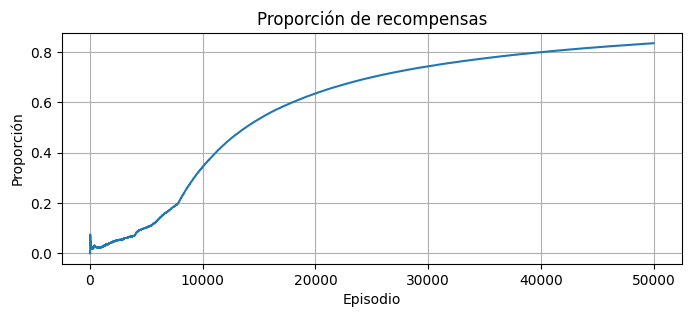

Máxima proporcion: 0.83584


In [27]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f'Máxima proporcion: {list_stats[-1]}')

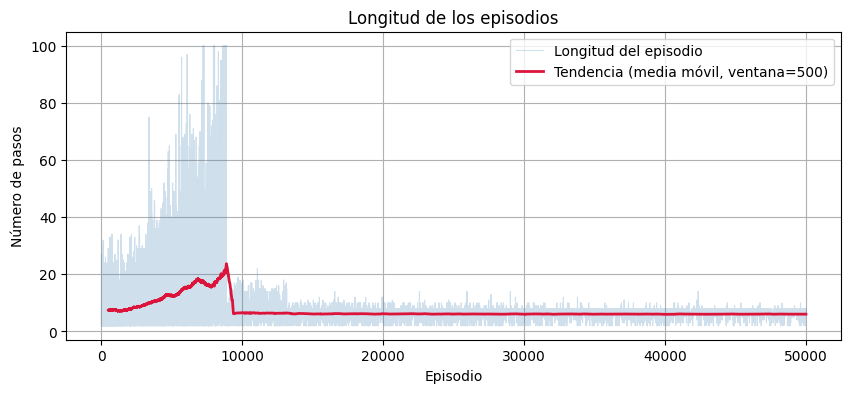

Longitud media final (últimos 1000 episodios): 6.06 pasos


In [16]:
#@title Longitud de episodios por número de episodio (4x4)

plot_lengths(list_lengths)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos')

####.
Mostramos los valores Q para cada estado. Cada estado tiene 4 valores, que se corresponden con las 4 acciones posibles.

In [17]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print('Valores Q para cada estado:\n', Q)

Valores Q para cada estado:
 [[0.99776172 0.99992455 0.9979377  0.99802122]
 [1.         0.         0.92701841 1.        ]
 [1.         0.02942388 0.         1.        ]
 [0.         0.         0.         0.        ]
 [0.99784696 0.9999299  0.         0.99754829]
 [0.         0.         0.         0.        ]
 [0.         1.         0.         1.        ]
 [0.         0.         0.         0.        ]
 [0.99776036 0.         0.99992635 0.99588112]
 [0.99768733 0.60561316 0.99997525 0.        ]
 [0.99737965 1.         0.         0.48543112]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.10701379 1.         1.        ]
 [0.20657237 0.9980055  1.         1.        ]
 [0.         0.         0.         0.        ]]


- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 4x4 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza $Q(s,\cdot)$, mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

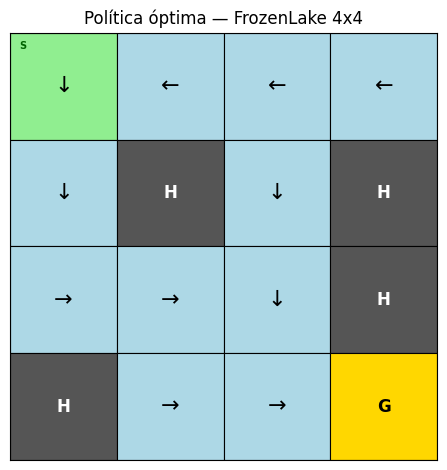

In [18]:
#@title Escenario con política óptima (4x4)
plot_scenario(env4, Q, title='Política óptima — FrozenLake 4x4')

In [19]:
# @title Política final
pi, actions = agent4.pi_star()
print('Política óptima obtenida\n', pi, f'\n Acciones {actions} \n Para el siguiente grid\n', env4.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 2, 1, 2 
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




### **3.3 Experimentación en el escenario 8x8**

Se realizan 50 000 episodios con $\varepsilon$ con decaimiento y `q_init=0.01`.

**¿Por qué es necesario `q_init` en 8×8?**

Con `Q=0` al inicio, `np.argmax(Q[s])` devuelve siempre la **acción 0 (LEFT)** debido al desempate de numpy (primer índice máximo). En el 8×8 esto crea un sesgo crítico:

- La política de comportamiento $b$ toma LEFT con probabilidad $1-\varepsilon+\varepsilon/4 = 0.7$.
- Desde el estado inicial (0,0), LEFT rebota contra la pared → el agente queda atrapado en la esquina superior izquierda.
- Los episodios raramente alcanzan la meta en (7,7): la difusión efectiva hacia la derecha/abajo es $\leq 20\%$ de probabilidad por paso.
- Sin episodios exitosos, $Q$ no se actualiza, y el sesgo se perpetúa.

Con `q_init=0.01`, $Q$ se inicializa con valores aleatorios distintos en $[0, 0.01]$, por lo que la acción greedy varía por estado desde el inicio. Esto garantiza exploración diversa en los primeros episodios, necesaria para salir del área superior-izquierda y encontrar el primer camino hasta la meta. El valor 0.01 es despreciable respecto a los valores aprendidos ($Q \approx 1$), por lo que no sesga el aprendizaje posterior.

Este es el parámetro `q_init` del Algoritmo 6: *"Q(s,a) $\in \mathbb{R}$ (arbitrarily)"* — la inicialización aleatoria es válida y necesaria en entornos con recompensas dispersas.

In [20]:
# @title Aprendizaje
agent8 = MonteCarloOffPolicyAgent(env8, epsilon=0.4, decay=True, discount_factor=1.0, q_init=0.01)
agent8.train(num_episodes=50000)
list_stats, list_lengths = agent8.stats()
Q = agent8.q_values

 10%|█         | 5050/50000 [00:08<01:32, 485.75it/s]

success: 0.1088, epsilon: 0.2000


 20%|██        | 10084/50000 [00:18<01:19, 499.72it/s]

success: 0.3271, epsilon: 0.1000


 30%|███       | 15047/50000 [00:29<01:19, 439.84it/s]

...

success: 0.5100, epsilon: 0.0250


 90%|█████████ | 45035/50000 [01:55<00:15, 322.51it/s]

success: 0.5002, epsilon: 0.0222


100%|██████████| 50000/50000 [02:12<00:00, 377.84it/s]

success: 0.4881, epsilon: 0.0200


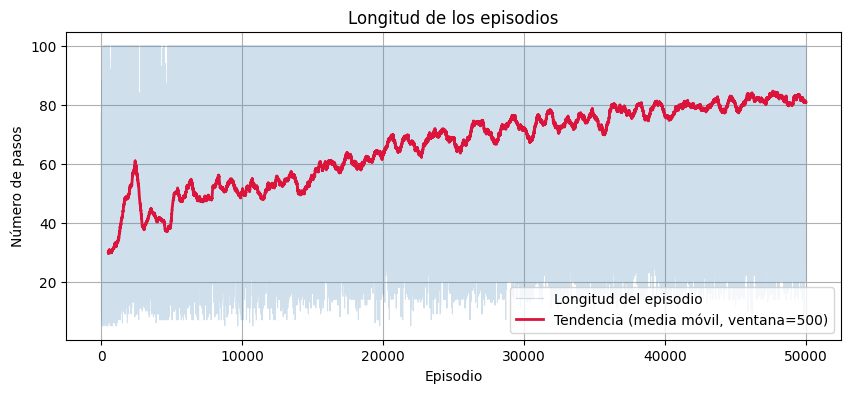

Longitud media final (últimos 1000 episodios): 81.98 pasos


In [21]:
#@title Longitud de episodios por número de episodio (8x8)

plot_lengths(list_lengths)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths[-1000:]):.2f} pasos')

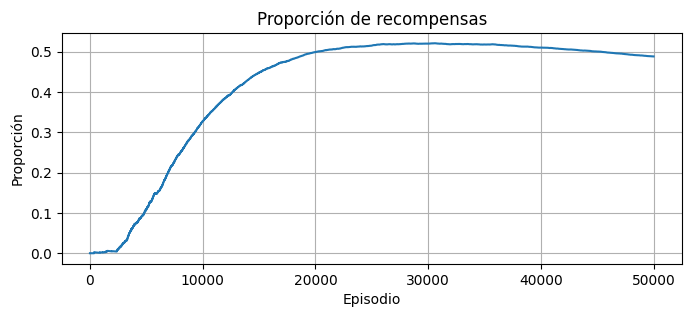

Máxima proporcion: 0.48808


In [22]:
#@title Proporción de aciertos por número de episodios

plot(list_stats)
print(f'Máxima proporcion: {list_stats[-1]}')

####.
Mostramos los valores Q para cada estado. Cada estado tiene 4 valores, que se corresponden con las 4 acciones posibles.

In [23]:
# @title Tabla de valores Q
LEFT, DOWN, RIGHT, UP = 0,1,2,3
print('Valores Q para cada estado:\n', Q)

Valores Q para cada estado:
 [[9.99956324e-01 9.98288781e-01 9.99956319e-01 7.29098533e-01]
 [9.99970485e-01 9.96716942e-01 9.98830614e-01 0.00000000e+00]
 [0.00000000e+00 9.49409494e-01 9.59267428e-01 7.10707219e-01]
 [9.52314196e-01 9.36266589e-01 9.52904852e-01 7.97379949e-01]
 [9.56743072e-01 9.58922573e-01 9.40318745e-01 9.03759296e-01]
 [9.53061195e-01 8.76035990e-01 9.05951845e-01 0.00000000e+00]
 [6.71473394e-01 9.75775477e-01 4.48300655e-01 5.90957953e-01]
 [9.42345173e-01 4.75556969e-01 0.00000000e+00 6.65097208e-01]
 [9.98033114e-01 9.98036507e-01 8.72443447e-01 0.00000000e+00]
 [8.98009145e-01 9.53964005e-01 9.58199051e-01 0.00000000e+00]
 [9.23146229e-01 9.71854123e-01 9.35391245e-01 9.27652628e-01]
 [9.65872209e-01 0.00000000e+00 8.98509407e-01 9.54839876e-01]
 [9.61908365e-01 8.52486385e-01 9.40595628e-01 9.25603612e-01]
 [9.60444731e-01 9.68166346e-01 9.88539525e-01 9.51297358e-01]
 [9.84964765e-01 9.69082064e-01 9.89170228e-01 9.79742825e-01]
 [9.87608549e-01 9.9057550

- También se muestra la política óptima (greedy) obtenida a partir del aprendizaje anterior.

- Cada estado tiene 4 valores, pero todos son 0 menos 1. Es decir, en cada estado se aplica de manera determinística una única acción.

- A continuación se visualiza el escenario 8x8 con las flechas de la política óptima superpuestas: cada celda libre (F) y la celda de salida (S) muestran la dirección que maximiza $Q(s,\cdot)$, mientras que los agujeros (H) y la meta (G) se identifican con su etiqueta y color característico.

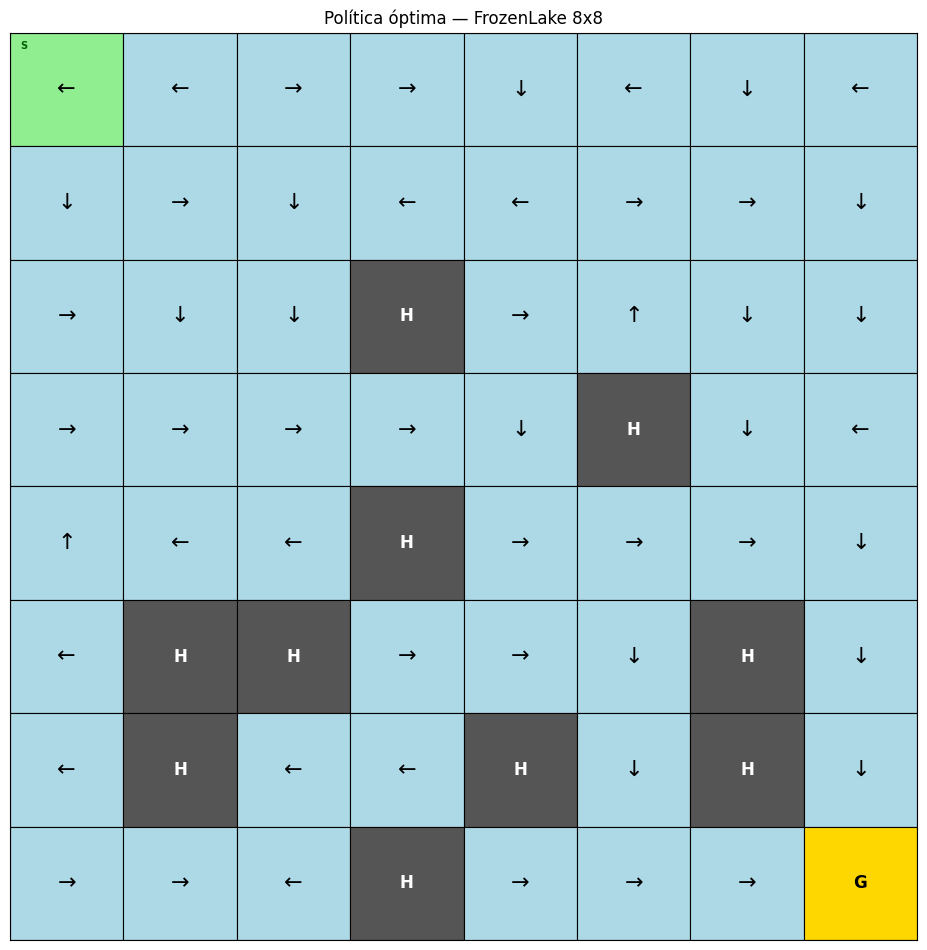

In [24]:
#@title Escenario con política óptima (8x8)
plot_scenario(env8, Q, title='Política óptima — FrozenLake 8x8')

In [25]:
# @title Política final
pi, actions = agent8.pi_star()
print('Política óptima obtenida\n', pi, f'\n Acciones {actions} \n Para el siguiente grid\n', env8.render())
print()

Política óptima obtenida
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 0,

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- El agente off-policy separa completamente la política de exploración ($b$) de la política que se mejora ($\pi$). Esto permite en principio reutilizar datos de cualquier política de comportamiento.

- La interrupción del bucle de retropropagación cuando $A_t \neq \arg\max Q[s]$ implica que en las primeras etapas del entrenamiento, con $\varepsilon$ alto, solo la **cola greedy** de cada episodio contribuye a las actualizaciones de Q. Esto ralentiza el aprendizaje inicial respecto al caso on-policy.

- Con decaimiento de $\varepsilon$, la política b se acerca a $\pi$, los pesos $W$ crecen hacia 1 y se reduce la varianza. El agente off-policy con decaimiento en 8x8 debería converger a tasas de éxito comparables al on-policy.

- El acumulador $C(s,a)$ actúa como denominador del IS ponderado. A diferencia del IS ordinario (divide por el número de visitas), el IS ponderado es sesgado pero tiene varianza mucho menor y es el método preferido en la práctica.

### **4.2 Propuestas para Estudios Futuros**

1. **Comparativa on-policy vs off-policy**: Ejecutar ambos agentes con los mismos hiperparámetros y semilla, y superponer sus curvas de tasa de éxito. ¿Cuántos episodios tarda más el off-policy en alcanzar la misma tasa?

2. **Efecto de $\varepsilon$ en la velocidad de convergencia**: Con $\varepsilon$ bajo, la política b es casi greedy y los pesos $W$ son cercanos a 1, pero la exploración es escasa. Con $\varepsilon$ alto, hay más exploración pero el bucle se interrumpe antes. ¿Existe un $\varepsilon$ óptimo para FrozenLake?

3. **IS ordinario vs IS ponderado**: Implementar la variante con IS ordinario y comparar la varianza de las estimaciones de Q.

4. **Política de comportamiento uniforme**: Usar una política aleatoria uniforme como $b$ (máxima exploración) y estudiar cómo afecta a la velocidad de aprendizaje y a la magnitud de los pesos $W$.